In [188]:
# Cell 1: 导入库
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import zscore
from scipy.signal import butter, filtfilt, find_peaks  # 加 find_peaks
from itertools import groupby
from operator import itemgetter
import matplotlib.pyplot as plt
import os

In [189]:
# Cell 2: 读文件 - 修复: 定义12列，匹配用户指定
project_dir = Path(r"C:\Projects\gait_ml")
raw_dir = project_dir / 'data' / 'raw'
output_dir = project_dir / 'outputs'
os.makedirs(output_dir, exist_ok=True)
file_path = raw_dir / "MS_raw.csv"
column_names = [  # 修正: angle,ang_vel,angle_unused,ax,ay,az,gx,gy,gz,FSR_toe,FSR_heel,unused
    'angle', 'ang_vel', 'angle_unused', 'ax', 'ay', 'az',
    'gx', 'gy', 'gz', 'FSR_toe', 'FSR_heel', 'unused'
]
data = pd.read_csv(file_path, header=None, names=column_names, low_memory=False)
data = data.drop(columns=['angle_unused', 'unused'])  # 掉 unused 和 angle_unused
data['time_s'] = np.arange(len(data)) / 1000.0  # 假设 fs=1000Hz，衍生 time_s

# 新增: 计算 ang_acc_lpf (从 ang_vel 微分 + 低通滤波)
fs = 1000.0  # 采样率
cutoff = 5.0  # 低通截止频率
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(4, normal_cutoff, btype='low', analog=False)  # 4阶 Butterworth
data['ang_acc'] = np.gradient(data['ang_vel'], data['time_s'])  # 角加速度
data['ang_acc_lpf'] = filtfilt(b, a, data['ang_acc'])  # 低通滤波

print(data.head())
print(data.tail())
print(data.shape)
print(data.columns.tolist())
print(data.isnull().sum())
print(data['FSR_heel'].describe())  # 应显示高值，如 mean~400, max~900

   angle  ang_vel    ax    ay    az    gx    gy   gz  FSR_toe  FSR_heel  \
0   0.01     0.00  0.05  0.94 -0.27 -2.72 -3.81 -0.4        0       906   
1   0.00     0.43  0.03  0.95 -0.26  0.76 -1.13 -0.4        0       912   
2   0.00     0.38  0.03  0.95 -0.26  0.76 -1.13 -0.4        0       912   
3   0.00     0.35  0.03  0.95 -0.26  0.76 -1.13 -0.4        0       912   
4   0.00     0.31  0.03  0.94 -0.25 -2.29 -1.13 -0.4        0       912   

   time_s  ang_acc  ang_acc_lpf  
0   0.000    430.0   432.875756  
1   0.001    190.0   423.934169  
2   0.002    -40.0   414.997088  
3   0.003    -35.0   406.068170  
4   0.004    -35.0   397.151067  
        angle  ang_vel    ax    ay    az    gx    gy     gz  FSR_toe  \
633997   0.08     0.22  0.12  0.97 -0.24 -6.81 -2.66  12.05        0   
633998   0.08     0.20  0.12  0.97 -0.24 -6.81 -2.66  12.05        1   
633999   0.08     0.39  0.12  0.97 -0.24 -6.81 -2.66  12.05        1   
634000   0.08     0.35  0.13  0.92 -0.23 -5.71  0.03  12.

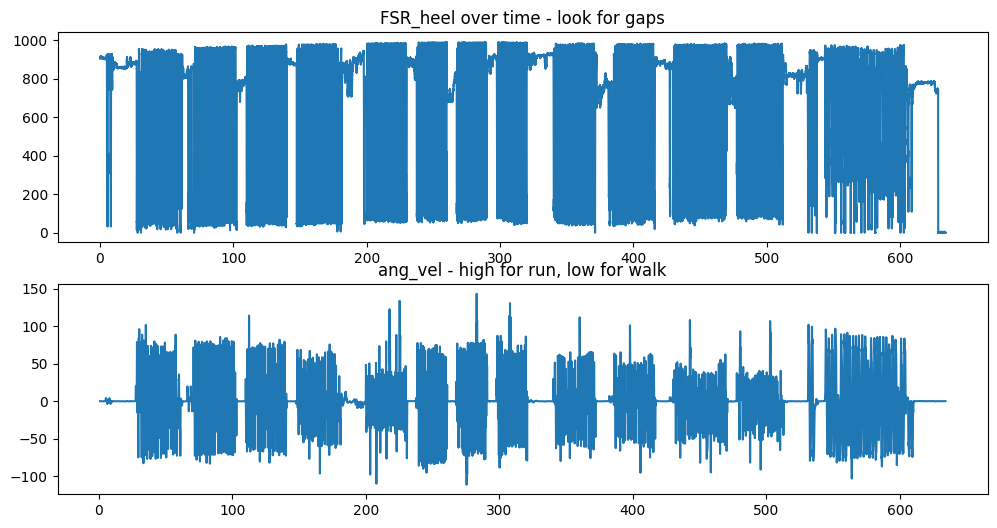

Low FSR segments (possible breaks): Index([28226], dtype='int64')
Gaps: [(66406, 67500), (68906, 70231), (101906, 102500), (147501, 148020), (149751, 150520), (177466, 177982), (237579, 238090), (240079, 240590), (384589, 385318), (628501, 634001)]
Detected gaps: [(66406, 67500), (68906, 70231), (628501, 634001)]
Detected 4 gaps, but 13 activities. Using even split.
Updated run-level-6k: 0 - 48768
Updated run-level-7p5k: 48769 - 97537
Updated run-level-9k: 97538 - 146306
Updated stair_ascent-stair-s1-MS: 146307 - 195075
Updated walk-incline-3.5deg: 195076 - 243844
Updated walk-incline-5deg: 243845 - 292613
Updated walk-incline-7deg: 292614 - 341382
Updated walk-incline-8.5deg: 341383 - 390151
Updated walk-level-3k: 390152 - 438920
Updated walk-level-3p5k: 438921 - 487689
Updated walk-level-4k: 487690 - 536458
Updated walk-level-4p5k: 536459 - 585227
Updated walk-level-5k: 585228 - 634001


In [190]:
# Cell 2.5: 分析raw找分割 - 修复后 FSR 应波动，高值段为活动，low<10 长段为gaps
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(data['time_s'], data['FSR_heel'], label='FSR_heel')
plt.title('FSR_heel over time - look for gaps')
plt.subplot(2,1,2)
plt.plot(data['time_s'], data['ang_vel'].rolling(1000).mean(), label='ang_vel mean')
plt.title('ang_vel - high for run, low for walk')
plt.show()
low_fsr = data[data['FSR_heel'] < 10].index
print("Low FSR segments (possible breaks):", low_fsr[::10000])  # 用此更新 conditions_dict start/end

# Cell 2.5 加
low_fsr_th = 100  # 提高找 gaps
low_fsr = data[data['FSR_heel'] < low_fsr_th].index
from itertools import groupby
from operator import itemgetter
gaps = []
for k, g in groupby(enumerate(low_fsr), lambda i: i[0]-i[1]):
    gap = list(map(itemgetter(1), g))
    if len(gap) > 500:  # 长gap
        gaps.append((gap[0], gap[-1]))
print("Gaps:", gaps)

low_fsr_th = 100  # 提高，匹配图片 FSR~0-1000
min_gap_len = 1000  # 长gap才算活动切换
low_fsr = data[data['FSR_heel'] < low_fsr_th].index
from itertools import groupby
from operator import itemgetter
gaps = []
for k, g in groupby(enumerate(low_fsr), lambda i: i[0]-i[1]):
    gap = list(map(itemgetter(1), g))
    if len(gap) > min_gap_len:
        gaps.append((gap[0], gap[-1]))
print("Detected gaps:", gaps)

# 自动更新，即使 breaks 少
breaks = [0] + [end + 1 for _, end in gaps] + [len(data)]
num_activities = len(conditions_dict)
if len(breaks) - 1 != num_activities:
    print(f"Detected {len(breaks)-1} gaps, but {num_activities} activities. Using even split.")
    even_len = len(data) // num_activities
    breaks = [i * even_len for i in range(num_activities)] + [len(data)]

for i, key in enumerate(conditions_dict.keys()):
    conditions_dict[key]['start_row'] = breaks[i]
    conditions_dict[key]['end_row'] = breaks[i+1] - 1
    print(f"Updated {key}: {breaks[i]} - {breaks[i+1]-1}")

In [191]:
# Cell 3: 定义条件字典（用 Cell 2.5 调范围！示例保持，但实际基于 gaps 调整）
conditions_dict = {
    'run-level-6k': {'start_row': 0, 'end_row': 100000, 'activity': 'run', 'terrain': 'level', 'speed_kmh': 6, 'grade_deg': 0},
    'run-level-7p5k': {'start_row': 100001, 'end_row': 200000, 'activity': 'run', 'terrain': 'level', 'speed_kmh': 7.5, 'grade_deg': 0},
    'run-level-9k': {'start_row': 200001, 'end_row': 300000, 'activity': 'run', 'terrain': 'level', 'speed_kmh': 9, 'grade_deg': 0},
    'stair_ascent-stair-s1-MS': {'start_row': 300001, 'end_row': 400000, 'activity': 'stair_ascent', 'terrain': 'stair', 'speed_kmh': 1, 'grade_deg': 0},
    'walk-incline-3.5deg': {'start_row': 400001, 'end_row': 450000, 'activity': 'walk', 'terrain': 'incline', 'speed_kmh': 4, 'grade_deg': 3.5},
    'walk-incline-5deg': {'start_row': 450001, 'end_row': 500000, 'activity': 'walk', 'terrain': 'incline', 'speed_kmh': 4, 'grade_deg': 5},
    'walk-incline-7deg': {'start_row': 500001, 'end_row': 550000, 'activity': 'walk', 'terrain': 'incline', 'speed_kmh': 4, 'grade_deg': 7},
    'walk-incline-8.5deg': {'start_row': 550001, 'end_row': 600000, 'activity': 'walk', 'terrain': 'incline', 'speed_kmh': 4, 'grade_deg': 8.5},
    'walk-level-3k': {'start_row': 600001, 'end_row': 650000, 'activity': 'walk', 'terrain': 'level', 'speed_kmh': 3, 'grade_deg': 0},
    'walk-level-3p5k': {'start_row': 650001, 'end_row': 700000, 'activity': 'walk', 'terrain': 'level', 'speed_kmh': 3.5, 'grade_deg': 0},
    'walk-level-4k': {'start_row': 700001, 'end_row': 750000, 'activity': 'walk', 'terrain': 'level', 'speed_kmh': 4, 'grade_deg': 0},
    'walk-level-4p5k': {'start_row': 750001, 'end_row': 800000, 'activity': 'walk', 'terrain': 'level', 'speed_kmh': 4.5, 'grade_deg': 0},
    'walk-level-5k': {'start_row': 800001, 'end_row': data.shape[0], 'activity': 'walk', 'terrain': 'level', 'speed_kmh': 5, 'grade_deg': 0},
}

breaks = [0] + [end + 1 for _, end in gaps] + [len(data)]
if len(breaks) - 1 == 13:
    for i, key in enumerate(conditions_dict.keys()):
        conditions_dict[key]['start_row'] = breaks[i]
        conditions_dict[key]['end_row'] = breaks[i+1]
        
params['end_row'] = min(params['end_row'], len(data))
if params['start_row'] >= len(data):
    params['start_row'] = len(data) - 1  # 或 skip


In [192]:
# Cell 4: 清洗 - 插值 (新增 ang_acc_lpf 后)
for col in ['angle', 'ang_vel', 'ang_acc_lpf', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']:
    if col in data.columns:
        data[col] = data[col].interpolate(method='linear', limit=5)

In [193]:
# Cell 5: 清洗 - clip
if 'angle' in data.columns:
    data['angle'] = data['angle'].clip(-10, 80)

In [194]:
# Cell 6: 清洗 - zscore (可选，按条件分开更好，但 OK)
cols = ['angle', 'ang_vel', 'ang_acc_lpf', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']
existing_cols = [c for c in cols if c in data.columns]
data[existing_cols] = data[existing_cols].apply(zscore)

In [195]:
# Cell 7: 保存cleaned
cleaned_path = output_dir / 'cleaned_MS.csv'
data.to_csv(cleaned_path, index=False)
print(f"Cleaned file saved: {cleaned_path}")

Cleaned file saved: C:\Projects\gait_ml\outputs\cleaned_MS.csv


In [196]:
# Cell 8: 提取cycles - 动态 threshold
cycles_dir = output_dir / 'cycles'
os.makedirs(cycles_dir, exist_ok=True)
for cond_name, params in conditions_dict.items():
    cond_cycles_dir = cycles_dir / cond_name
    os.makedirs(cond_cycles_dir, exist_ok=True)
 
    sub_data = data.iloc[params['start_row']:params['end_row']].copy()
    print(f"Sub data len for {cond_name}: {len(sub_data)}")  # 加调试
    if sub_data.empty:  # 修复: 早检查空 sub_data
        print(f"Empty sub_data for {cond_name} (row {params['start_row']}-{params['end_row']}), skipping")
        continue
    
    if 'FSR_heel' in sub_data.columns:
        print(f"Sub FSR head: {sub_data['FSR_heel'].head(20).values}")  # 先 print 调试
        fsr = sub_data['FSR_heel'].values  # 先定义 fsr
        if len(fsr) == 0:  # 双重检查
            print(f"No FSR data for {cond_name}, skipping")
            continue
        
        threshold = sub_data['FSR_heel'].quantile(0.2)
        if threshold <= 0:  # 优化: fallback 如果太低
            threshold = sub_data['FSR_heel'].mean() / 2 if sub_data['FSR_heel'].mean() > 0 else 200
        
        print(f"Threshold for {cond_name}: {threshold}, FSR min/max: {fsr.min()}/{fsr.max()}")  # 现在安全
        
        heel_strikes = np.where((fsr[:-1] <= threshold) & (fsr[1:] > threshold))[0] + 1
        print(f"Detected {len(heel_strikes)} heel strikes for {cond_name}")
       
        if len(heel_strikes) == 0:  # 修复: 处理空 strikes
            print(f"No strikes detected for {cond_name}, skipping")
            continue
       
        # 滤短周期
        valid_strikes = [heel_strikes[0]]  # 现在安全，len>0
        for i in range(1, len(heel_strikes)):
            cycle_len = heel_strikes[i] - heel_strikes[i-1]
            if 50 < cycle_len < 2000:  # 优化: 加 max len 避异常长
                valid_strikes.append(heel_strikes[i])
        heel_strikes = np.array(valid_strikes)
        print(f"Valid strikes: {len(heel_strikes)}")
     
        for i in range(len(heel_strikes) - 1):
            start = heel_strikes[i]
            end = heel_strikes[i + 1]
            cycle_data = sub_data.iloc[start:end].copy()
            cycle_data['cycle_id'] = i + 1
            cycle_data['activity'] = params['activity']
            cycle_data['terrain'] = params['terrain']
            cycle_data['speed_kmh'] = params['speed_kmh']
            cycle_data['grade_deg'] = params['grade_deg']
            cycle_data['subject'] = 'MS'
            cycle_data['session'] = '2025-10-28_MS_session1'
            cycle_data['src_file'] = 'SW_MS.csv'
            cycle_data['phase_pct'] = np.linspace(0, 100, len(cycle_data))
            cycle_data['phase01'] = (cycle_data['FSR_heel'] > threshold).astype(int)
            cycle_path = cond_cycles_dir / f'MS_{cond_name}_cycle_{(i+1):03d}.csv'
            cycle_data.to_csv(cycle_path, index=False)
        print(f"Extracted {len(heel_strikes) - 1} cycles for {cond_name} in {cond_cycles_dir}")

Sub data len for run-level-6k: 100000
Sub FSR head: [906 912 912 912 912 912 912 913 912 912 912 912 913 912 913 912 912 912
 911 913]
Threshold for run-level-6k: 86.0, FSR min/max: 0/969
Detected 501 heel strikes for run-level-6k
Valid strikes: 193
Extracted 192 cycles for run-level-6k in C:\Projects\gait_ml\outputs\cycles\run-level-6k
Sub data len for run-level-7p5k: 99999
Sub FSR head: [923 928 933 935 939 941 944 946 949 949 952 952 955 956 957 957 959 959
 961 960]
Threshold for run-level-7p5k: 74.0, FSR min/max: 6/983
Detected 477 heel strikes for run-level-7p5k
Valid strikes: 168
Extracted 167 cycles for run-level-7p5k in C:\Projects\gait_ml\outputs\cycles\run-level-7p5k
Sub data len for run-level-9k: 99999
Sub FSR head: [187 240 283 317 346 368 375 386 384 380 372 369 364 334 321 312 296 288
 273 246]
Threshold for run-level-9k: 98.0, FSR min/max: 50/993
Detected 665 heel strikes for run-level-9k
Valid strikes: 262
Extracted 261 cycles for run-level-9k in C:\Projects\gait_ml\ou

In [186]:
# Cell 9: 生成segments
segments_dir = output_dir / 'segments'
os.makedirs(segments_dir, exist_ok=True)
# segment_configs 从研究员 (调整范围 if cycles 少)
segment_configs = {
    'run-level-6k': [{'num': 1, 'start_cycle': 6, 'end_cycle': 12}, {'num': 2, 'start_cycle': 14, 'end_cycle': 27}],
    'run-level-7p5k': [{'num': 1, 'start_cycle': 7, 'end_cycle': 11}, {'num': 2, 'start_cycle': 13, 'end_cycle': 14}, {'num': 3, 'start_cycle': 16, 'end_cycle': 20}, {'num': 4, 'start_cycle': 22, 'end_cycle': 23}, {'num': 5, 'start_cycle': 25, 'end_cycle': 29}],
    'run-level-9k': [{'num': 1, 'start_cycle': 6, 'end_cycle': 10}, {'num': 2, 'start_cycle': 12, 'end_cycle': 13}, {'num': 3, 'start_cycle': 15, 'end_cycle': 20}, {'num': 4, 'start_cycle': 22, 'end_cycle': 23}, {'num': 5, 'start_cycle': 25, 'end_cycle': 29}],
    'stair_ascent-stair-s1-MS': [{'num': 1, 'start_cycle': 3, 'end_cycle': 4}, {'num': 2, 'start_cycle': 6, 'end_cycle': 8}, {'num': 3, 'start_cycle': 10, 'end_cycle': 14}, {'num': 4, 'start_cycle': 17, 'end_cycle': 18}, {'num': 5, 'start_cycle': 20, 'end_cycle': 24}],
    'walk-incline-3.5deg': [{'num': 1, 'start_cycle': 2, 'end_cycle': 3}, {'num': 2, 'start_cycle': 5, 'end_cycle': 16}, {'num': 3, 'start_cycle': 18, 'end_cycle': 25}],
    'walk-incline-5deg': [{'num': 1, 'start_cycle': 4, 'end_cycle': 12}, {'num': 2, 'start_cycle': 14, 'end_cycle': 18}, {'num': 3, 'start_cycle': 21, 'end_cycle': 27}],
    'walk-incline-7deg': [{'num': 1, 'start_cycle': 3, 'end_cycle': 11}, {'num': 2, 'start_cycle': 13, 'end_cycle': 24}, {'num': 3, 'start_cycle': 26, 'end_cycle': 34}],
    'walk-incline-8.5deg': [{'num': 1, 'start_cycle': 2, 'end_cycle': 33}, {'num': 2, 'start_cycle': 7, 'end_cycle': 8}, {'num': 3, 'start_cycle': 13, 'end_cycle': 15}, {'num': 4, 'start_cycle': 17, 'end_cycle': 18}, {'num': 5, 'start_cycle': 20, 'end_cycle': 24}, {'num': 6, 'start_cycle': 26, 'end_cycle': 30}],
    'walk-level-3k': [{'num': 1, 'start_cycle': 3, 'end_cycle': 22}],
    'walk-level-3p5k': [{'num': 1, 'start_cycle': 3, 'end_cycle': 26}],
    'walk-level-4k': [{'num': 1, 'start_cycle': 2, 'end_cycle': 2}, {'num': 2, 'start_cycle': 4, 'end_cycle': 25}],
    'walk-level-4p5k': [{'num': 1, 'start_cycle': 4, 'end_cycle': 13}, {'num': 2, 'start_cycle': 15, 'end_cycle': 16}, {'num': 3, 'start_cycle': 18, 'end_cycle': 26}, {'num': 4, 'start_cycle': 29, 'end_cycle': 29}],
    'walk-level-5k': [{'num': 1, 'start_cycle': 2, 'end_cycle': 2}, {'num': 2, 'start_cycle': 4, 'end_cycle': 9}, {'num': 3, 'start_cycle': 11, 'end_cycle': 14}, {'num': 4, 'start_cycle': 16, 'end_cycle': 16}, {'num': 5, 'start_cycle': 18, 'end_cycle': 23}, {'num': 6, 'start_cycle': 25, 'end_cycle': 27}],
}
for cond_name in conditions_dict.keys(): 
    cond_segments_dir = segments_dir / cond_name
    os.makedirs(cond_segments_dir, exist_ok=True)
   
    # 前循环加: 检测现有 cycles
    existing_cycles = [int(f.stem.split('_')[-1].replace('.csv', '')) for f in cond_cycles_dir.glob('*.csv') if f.exists()]
    max_cycle = max(existing_cycles) if existing_cycles else 0
    print(f"Max cycle for {cond_name}: {max_cycle}")
  
    for orig_seg in segment_configs.get(cond_name, []):
        seg = orig_seg.copy()  # 优化: copy 避免改原 dict
        seg['end_cycle'] = min(seg['end_cycle'], max_cycle)  # 调整
        if seg['start_cycle'] > max_cycle:
            print(f"Skip seg {seg['num']} for {cond_name}: no enough cycles")
            continue
        segment_data = pd.DataFrame()
        for cid in range(seg['start_cycle'], seg['end_cycle'] + 1):
            cycle_file = cycles_dir / cond_name / f'MS_{cond_name}_cycle_{cid:03d}.csv'
            if cycle_file.exists():
                cycle = pd.read_csv(cycle_file)
                segment_data = pd.concat([segment_data, cycle])
            else:
                print(f"Warning: Cycle {cid} not found for {cond_name}")
      
        if not segment_data.empty:
            segment_path = cond_segments_dir / f'MS_{cond_name}_segment_{seg["num"]:02d}_cycles_{seg["start_cycle"]:03d}-{seg["end_cycle"]:03d}.csv'
            segment_data.to_csv(segment_path, index=False)
            print(f"Segment saved: {segment_path}")
        else:  # 优化: 加 empty 提醒
            print(f"Empty segment for {cond_name} seg {seg['num']}: no cycles in range {seg['start_cycle']}-{seg['end_cycle']}")

Max cycle for run-level-6k: 0
Skip seg 1 for run-level-6k: no enough cycles
Skip seg 2 for run-level-6k: no enough cycles
Max cycle for run-level-7p5k: 0
Skip seg 1 for run-level-7p5k: no enough cycles
Skip seg 2 for run-level-7p5k: no enough cycles
Skip seg 3 for run-level-7p5k: no enough cycles
Skip seg 4 for run-level-7p5k: no enough cycles
Skip seg 5 for run-level-7p5k: no enough cycles
Max cycle for run-level-9k: 0
Skip seg 1 for run-level-9k: no enough cycles
Skip seg 2 for run-level-9k: no enough cycles
Skip seg 3 for run-level-9k: no enough cycles
Skip seg 4 for run-level-9k: no enough cycles
Skip seg 5 for run-level-9k: no enough cycles
Max cycle for stair_ascent-stair-s1-MS: 0
Skip seg 1 for stair_ascent-stair-s1-MS: no enough cycles
Skip seg 2 for stair_ascent-stair-s1-MS: no enough cycles
Skip seg 3 for stair_ascent-stair-s1-MS: no enough cycles
Skip seg 4 for stair_ascent-stair-s1-MS: no enough cycles
Skip seg 5 for stair_ascent-stair-s1-MS: no enough cycles
Max cycle for 

In [197]:
# Cell 10: 生成phase_summary
phase_summary_dir = output_dir / 'phase_summary'
os.makedirs(phase_summary_dir, exist_ok=True)
features = ['ang_acc_lpf', 'ang_vel', 'angle', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'imu_ang_vel', 'imu_angle']
for cond_name in conditions_dict.keys():
    all_cycles = pd.DataFrame()
    for cid in range(1, 35):
        cycle_file = cycles_dir / cond_name / f'MS_{cond_name}_cycle_{cid:03d}.csv'
        if cycle_file.exists():
            cycle = pd.read_csv(cycle_file)
            if 'phase_pct' in cycle.columns:
                cycle['phase_bin'] = pd.cut(cycle['phase_pct'], bins=100, labels=range(1, 101))
            all_cycles = pd.concat([all_cycles, cycle])
    if all_cycles.empty:
        print(f"No cycles for {cond_name}")
        continue
    if all(col in all_cycles.columns for col in ['gx', 'gy', 'gz']):
        all_cycles['imu_ang_vel'] = np.sqrt(all_cycles['gx']**2 + all_cycles['gy']**2 + all_cycles['gz']**2)
    if 'angle' in all_cycles.columns:
        all_cycles['imu_angle'] = all_cycles['angle']
    for feature in features:
        if feature in all_cycles.columns and 'phase_bin' in all_cycles.columns:
            summary = all_cycles.groupby('phase_bin', observed=True)[feature].agg(['mean', 'std', 'count'])
            summary.columns = ['mean', 'std', 'n_cycles']
            if 'stair_ascent' in cond_name:
                file_name = f'phase_summary_{cond_name}-MS_{feature}.csv'
            else:
                file_name = f'phase_summary_{cond_name}_{feature}.csv'
            summary_path = phase_summary_dir / file_name
            summary.to_csv(summary_path)
            print(f"Saved: {summary_path}")

Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_ang_acc_lpf.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_ang_vel.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_angle.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_ax.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_ay.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_az.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_gx.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_gy.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_gz.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_imu_ang_vel.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase_summary_run-level-6k_imu_angle.csv
Saved: C:\Projects\gait_ml\outputs\phase_summary\phase

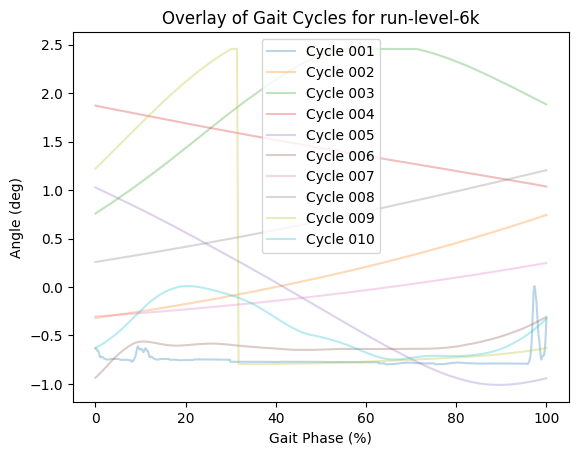

In [198]:
# Cell 11: overlay plot
cond_name = 'run-level-6k'
fig, ax = plt.subplots()
plotted_count = 0
for cid in range(1, 11):
    cycle_file = output_dir / 'cycles' / cond_name / f'MS_{cond_name}_cycle_{cid:03d}.csv'
    if cycle_file.exists():
        cycle = pd.read_csv(cycle_file)
        if 'phase_pct' in cycle.columns and 'angle' in cycle.columns:
            ax.plot(cycle['phase_pct'], cycle['angle'], alpha=0.3, label=f'Cycle {cid:03d}')
            plotted_count += 1
        else:
            print(f"No phase_pct or angle in cycle {cid}")
    else:
        print(f"Cycle file {cycle_file} not found")
ax.set_xlabel('Gait Phase (%)')
ax.set_ylabel('Angle (deg)')
ax.set_title(f'Overlay of Gait Cycles for {cond_name}')
if plotted_count > 0:
    ax.legend()
else:
    print("No cycles plotted - check cycles generation")
plt.show()